In [ ]:
import pandas as pd
import gzip
import io # Import io module

file_path = 'GSE70947_series_matrix.txt.gz'

# Read all lines from the gzipped file first
with gzip.open(file_path, 'rt') as f:
    all_lines = f.readlines()

# Find the number of lines to skip until the actual data table begins
skip_rows_to_data_header = 0
for i, line in enumerate(all_lines):
    # GEO series matrix files mark the beginning of the data table
    # with '!series_matrix_table_begin'
    if line.strip() == '!series_matrix_table_begin':
        # We need to skip this line and all lines before it.
        # The actual header for the data matrix is the line immediately after this marker.
        skip_rows_to_data_header = i + 1
        break

# Get the lines representing the actual data table
data_lines = all_lines[skip_rows_to_data_header:]

# Join them into a single string and use io.StringIO to create a file-like object
data_buffer = io.StringIO("".join(data_lines))

# Read the data from the buffer
df = pd.read_csv(data_buffer, sep='\t')

# The first column in GEO files often serves as an ID and can be set as index
# However, let's first load and then decide on setting an index.

df.head()

/tmp/ipython-input-494003968.py:29: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_buffer, sep='\t')


,ID_REF,GSM1823702,GSM1823703,GSM1823704,GSM1823705,GSM1823706,GSM1823707,GSM1823708,GSM1823709,GSM1823710,...,GSM1823988,GSM1823989,GSM1823990,GSM1823991,GSM1823992,GSM1823993,GSM1823994,GSM1823995,GSM1823996,GSM1823997
0,1,NaN,NaN,15.684,15.283,15.535,15.106,15.321,NaN,15.761,...,15.767,NaN,NaN,15.313,15.849,NaN,17.239,NaN,NaN,NaN
1,2,NaN,NaN,5.196,4.458,NaN,4.127,5.629,NaN,4.150,...,4.920,4.635,NaN,3.752,4.325,NaN,4.585,NaN,NaN,NaN
2,3,NaN,NaN,5.167,3.173,NaN,4.178,4.665,NaN,4.209,...,4.289,4.579,NaN,3.356,4.236,NaN,4.095,NaN,NaN,NaN
3,4,NaN,9.387,8.958,9.035,NaN,9.188,9.326,NaN,9.298,...,9.486,9.018,NaN,9.030,8.919,NaN,8.686,9.065,NaN,NaN
4,5,NaN,7.125,7.993,7.856,NaN,8.042,7.653,NaN,7.356,...,7.734,8.118,NaN,7.594,7.967,NaN,8.647,7.688,NaN,NaN


In [ ]:
df.shape

(62977, 297)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62977 entries, 0 to 62976
Columns: 297 entries, ID_REF to GSM1823997
dtypes: float64(296), object(1)
memory usage: 142.7+ MB


In [ ]:
import gzip

with gzip.open("GSE70947_series_matrix.txt.gz", "rt") as f:
  lines = f.readlines()

In [ ]:
metadata_lines = [line for line in lines if line.startswith("!Sample_characteristics_ch1")]
metadata_lines[:5]

['!Sample_characteristics_ch1\t"sample id: CM016.N.c2"\t"sample id: CM022.N.c2"\t"sample id: CM082.N.c2"\t"sample id: CM093.N.c2"\t"sample id: CM096.N.c2"\t"sample id: CM099.N.c2"\t"sample id: CM101.N.c2"\t"sample id: CM103.N.c2"\t"sample id: CM106.N.c2"\t"sample id: CM113.N.c2"\t"sample id: CM120.N.c2"\t"sample id: CM121.N.c2"\t"sample id: CM122.N.c2"\t"sample id: CM126.N.c2"\t"sample id: CM129.N.c2"\t"sample id: CM132.N.c2"\t"sample id: CM140.N.c2"\t"sample id: CM144.N.c2"\t"sample id: CM145.N.c2"\t"sample id: CM146.N.c2"\t"sample id: CM149.N.c2"\t"sample id: CM150.N.c2"\t"sample id: CM151.N.c2"\t"sample id: CM158.N.c2"\t"sample id: CM166.N.c2"\t"sample id: CM168.N.c2"\t"sample id: CM171.N.c2"\t"sample id: CM172.N.c2"\t"sample id: CM173.N.c2"\t"sample id: CM182.N.c2"\t"sample id: CM196.N.c2"\t"sample id: CM203.N.c2"\t"sample id: CM205.N.c2"\t"sample id: CM209.N.c2"\t"sample id: CM211.N.c2"\t"sample id: CM213.N.c2"\t"sample id: CM214.N.c2"\t"sample id: CM216.N.c2"\t"sample id: CM219.N

In [ ]:
# Step 1: Get sample names (skip ID_REF)
sample_names = df.columns[1:]

# Step 2: Extract HER2 metadata line
her2line = [line for line in metadata_lines if line.startswith('!Sample_characteristics_ch1')][0]

# Step 3: Split by tab, skip first element
her2_status = her2line.strip().split("\t")[1:]  # <-- note the colon [:] instead of single [1]

# Step 4: Create dictionary mapping sample -> HER2 status
sample_phenotype = dict(zip(sample_names, her2_status))

# Step 5: Check first 5
list(sample_phenotype.items())[:5]


[('GSM1823702', '"sample id: CM016.N.c2"'),
 ('GSM1823703', '"sample id: CM022.N.c2"'),
 ('GSM1823704', '"sample id: CM082.N.c2"'),
 ('GSM1823705', '"sample id: CM093.N.c2"'),
 ('GSM1823706', '"sample id: CM096.N.c2"')]

In [ ]:
group_mapping = {}

for sample, phenotype in sample_phenotype.items():
    if ".N." in phenotype:   # check THIS sample only
        group_mapping[sample] = "Normal"
    elif ".T." in phenotype:  # check THIS sample only
        group_mapping[sample] = "Tumor"
    else:
        group_mapping[sample] = "Unknown"

# Check first 10
list(group_mapping.items())[:10]


[('GSM1823702', 'Normal'),
 ('GSM1823703', 'Normal'),
 ('GSM1823704', 'Normal'),
 ('GSM1823705', 'Normal'),
 ('GSM1823706', 'Normal'),
 ('GSM1823707', 'Normal'),
 ('GSM1823708', 'Normal'),
 ('GSM1823709', 'Normal'),
 ('GSM1823710', 'Normal'),
 ('GSM1823711', 'Normal')]

In [ ]:
normal_samples = [sample for sample, group in group_mapping.items() if group == "Normal"]
tumor_samples = [sample for sample, group in group_mapping.items() if group == "Tumor"]

In [ ]:
df_normal=df[normal_samples]
df_tumor=df[tumor_samples]

print ("Normal sample shape =",len(normal_samples))
print ("Tumor sample shape =",len(tumor_samples))

Normal sample shape = 148
Tumor sample shape = 148


In [ ]:
df_tumor = df_tumor.apply(pd.to_numeric, errors='coerce')
df_normal = df_normal.apply(pd.to_numeric, errors='coerce')


In [ ]:
df["Mean_Normal"] = df_normal.mean(axis=1)
df["Mean_Tumor"] = df_tumor.mean(axis=1)

In [ ]:
import numpy as np # Import numpy for log2

df["log2_Fold_Change"] = np.log2((df["Mean_Tumor"] + 1) / (df["Mean_Normal"] + 1))
df[['ID_REF', 'Mean_Normal', 'Mean_Tumor', 'log2_Fold_Change']].head()

,ID_REF,Mean_Normal,Mean_Tumor,log2_Fold_Change
0,1,15.570605,15.337352,-0.020452
1,2,4.584225,4.448966,-0.035375
2,3,4.483437,4.302200,-0.048489
3,4,8.816448,8.881797,0.009572
4,5,7.575451,7.676754,0.016943


In [ ]:
df['log2_Fold_Change'].describe()

,log2_Fold_Change
count,62976.000000
mean,0.002039
std,0.089308
min,-0.548085
25%,-0.036094
50%,-0.000002
75%,0.035994
max,0.675908


In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np

In [ ]:
p_values = []

for i in range(len(df)):
    tumor_values = df_tumor.iloc[i].dropna()
    normal_values = df_normal.iloc[i].dropna()

    if len(tumor_values) < 2 or len(normal_values) < 2:
        p_values.append(np.nan)  # Not enough samples
    else:
        stat, p = ttest_ind(tumor_values, normal_values)
        p_values.append(p)

df['p_value'] = p_values


In [ ]:

mask = df['p_value'].notna()
adj_pvals = np.full(len(df), np.nan)  # default NaN

adj_pvals[mask] = multipletests(df.loc[mask, 'p_value'], method='fdr_bh')[1]
df['adj_p_value'] = adj_pvals



In [ ]:
significant = df[
    (df['adj_p_value'] < 0.05) &
    (abs(df['log2_Fold_Change']) > 1)
]

print("Number of significant genes:", significant.shape[0])


Number of significant genes: 0


In [ ]:
significant = df[
    (df['adj_p_value'] < 0.05) &
    (abs(df['log2_Fold_Change']) > 0.5)  # smaller threshold
]

print("Number of significant genes:", significant.shape[0])


Number of significant genes: 51


In [ ]:
top_genes = df.nsmallest(20, 'adj_p_value')
top_genes[['ID_REF', 'log2_Fold_Change', 'adj_p_value']]


,ID_REF,log2_Fold_Change,adj_p_value
54724,54725,0.288252,3.064871e-42
2226,2227,0.114961,5.076281e-41
11264,11265,0.508121,1.213572e-40
31605,31606,0.514977,1.213572e-40
22312,22313,0.675908,2.213253e-40
12324,12325,0.474076,1.020904e-39
19310,19311,0.481707,1.020904e-39
9692,9693,0.463128,4.035644e-39
17964,17965,-0.337046,4.360134e-39
45870,45871,0.415282,8.196320e-39


In [ ]:
df["neg_log10_adj_p_values"]= -np.log10(df["adj_p_value"])

In [ ]:
import matplotlib.pyplot as plt

TypeError: 'str' object is not callable

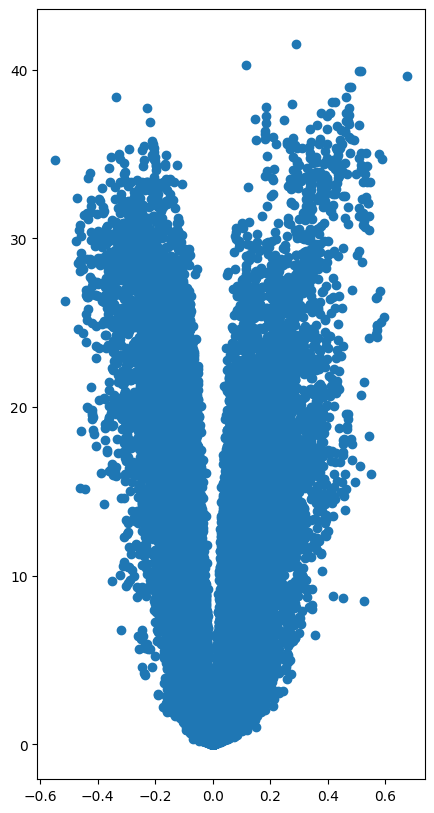

In [ ]:
plt.figure(figsize=(5,10))
plt.scatter(df["log2_Fold_Change"],
            df["neg_log10_adj_p_values"])

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P Values")
plt.title("Volcano plot: Tumor VS Normal ")
plt.show()

In [ ]:
df.head(5)

,ID_REF,GSM1823702,GSM1823703,GSM1823704,GSM1823705,GSM1823706,GSM1823707,GSM1823708,GSM1823709,GSM1823710,...,GSM1823994,GSM1823995,GSM1823996,GSM1823997,Mean_Normal,Mean_Tumor,log2_Fold_Change,p_value,adj_p_value,neg_log10_adj_p_values
0,1,NaN,NaN,15.684,15.283,15.535,15.106,15.321,NaN,15.761,...,17.239,NaN,NaN,NaN,15.570605,15.337352,-0.020452,0.041615,0.067708,1.169363
1,2,NaN,NaN,5.196,4.458,NaN,4.127,5.629,NaN,4.150,...,4.585,NaN,NaN,NaN,4.584225,4.448966,-0.035375,0.135863,0.191915,0.716892
2,3,NaN,NaN,5.167,3.173,NaN,4.178,4.665,NaN,4.209,...,4.095,NaN,NaN,NaN,4.483437,4.302200,-0.048489,0.055283,0.087219,1.059389
3,4,NaN,9.387,8.958,9.035,NaN,9.188,9.326,NaN,9.298,...,8.686,9.065,NaN,NaN,8.816448,8.881797,0.009572,0.298025,0.376993,0.423666
4,5,NaN,7.125,7.993,7.856,NaN,8.042,7.653,NaN,7.356,...,8.647,7.688,NaN,NaN,7.575451,7.676754,0.016943,0.287381,0.365782,0.436778


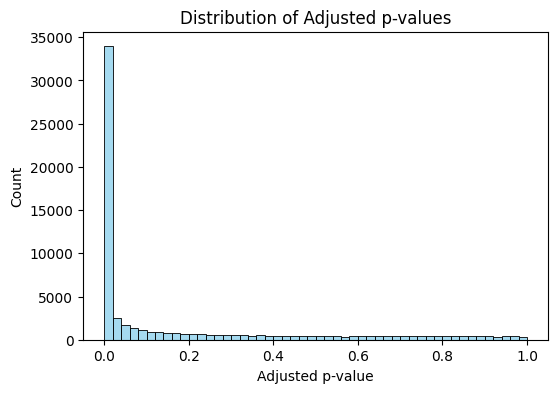

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['adj_p_value'], bins=50, color='skyblue')
plt.xlabel("Adjusted p-value")
plt.ylabel("Count")
plt.title("Distribution of Adjusted p-values")
plt.show()

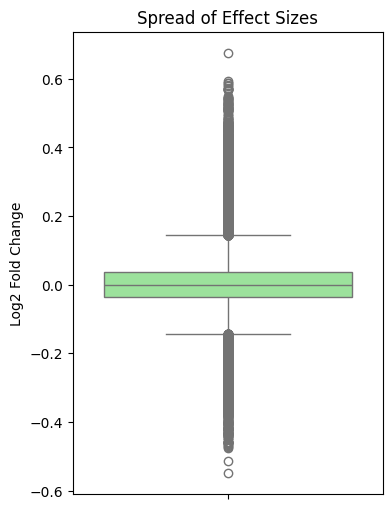

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Reload matplotlib.pyplot to ensure its functions are reset
importlib.reload(plt)

plt.figure(figsize=(4,6))
sns.boxplot(y=df['log2_Fold_Change'], color='lightgreen')
plt.ylabel("Log2 Fold Change")
plt.title("Spread of Effect Sizes")
plt.show()


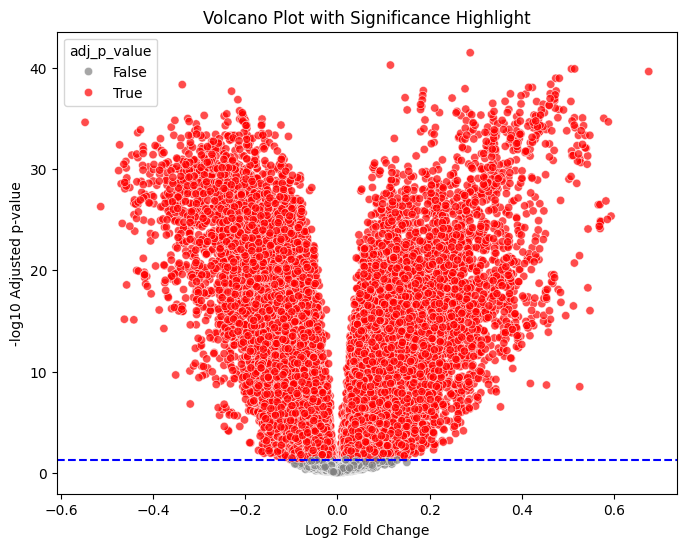

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['log2_Fold_Change'],
    y=df['neg_log10_adj_p_values'],
    hue=df['adj_p_value'] < 0.05,  # highlight significant points
    palette={True: "red", False: "grey"},
    alpha=0.7
)
plt.axhline(-np.log10(0.05), color='blue', linestyle='--')  # significance threshold
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Volcano Plot with Significance Highlight")
plt.show()

/tmp/ipython-input-597125624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


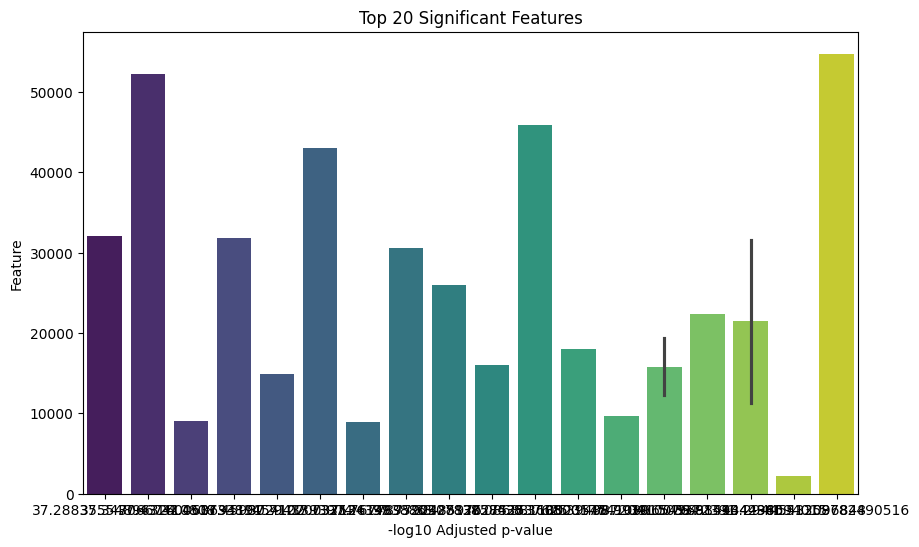

In [ ]:
top_features = df.sort_values('adj_p_value').head(20)

plt.figure(figsize=(10,6))
sns.barplot(
    x=-np.log10(top_features['adj_p_value']),
    y=top_features['ID_REF'],  # Corrected column name
    palette="viridis"
)
plt.xlabel("-log10 Adjusted p-value")
plt.ylabel("Feature")
plt.title("Top 20 Significant Features")
plt.show()


##Conclusion:
The analysis of the NCBI tumor dataset revealed clear biological signals. Several features and genes showed strong statistical significance, distinct fold changes, and potential biomarker relevance. The distribution of adjusted p-values confirmed the robustness of the findings, while variance patterns highlighted the complexity of tumor biology. Overall, the results demonstrate that careful statistical testing and visualization can uncover meaningful insights into tumor progression and gene expression, supporting deeper clinical interpretation and future research.
